# Phase 0 — ASPIRe / TAO-Amodal Data Exploration

**Goal of this notebook:** before writing any model code, confirm that:
1. The ASPIRe annotation JSONs parse the way the paper says they do.
2. The annotation indexing scheme (segments_info / appearances / situations /
   positions / interactions / relations) is understood correctly — verified
   **visually**, not just by reading the paper.
3. The ASPIRe annotations actually resolve to frame files you have on disk
   right now, and we know exactly what's missing.
4. We get a first look at label distributions (they are known to be very
   long-tailed — this affects loss design later).

This notebook does not train anything. It only reads, cross-references, and
visualizes. Every "finding" cell below prints something you should eyeball,
not just trust.


In [1]:
import json
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

%matplotlib inline


## 0.0 Known finding: `category_id` decoding

Before you run this: **`category_id` in `segments_info`/`annotations` is the
real LVIS v0.5 category id (1-1230, with gaps) — it is NOT a positional
index into ASPIRe's own `thing_classes`/`stuff_classes` arrays.**

Those two arrays look like they were built by taking LVIS v0.5's category
names and splitting them into "thing" vs "stuff" buckets, which silently
shifts every position after each removed entry. Direct indexing (`thing_classes[category_id]`)
and even an off-by-one correction both decode to garbage (e.g. `805` looked
like `"phonebook"`, when it's actually **person** — LVIS just names the
category after its alphabetically-first synonym: `baby/child/boy/girl/man/
woman/person/human`).

Fix: use the real LVIS v0.5 `id -> name` mapping (1,230 categories),
provided alongside this notebook as `lvis_v0_5_categories.json`. Place it at:

```
data/TAO_Amodal_Dataset/lvis_v0_5_categories.json
```

This notebook decodes categories through that file instead of the local
`thing_classes`/`stuff_classes` arrays.


## 0.1 Paths

Adjust `PROJECT_ROOT` if this notebook is not sitting at `src/notebooks/`.
Everything else is derived from it, matching the tree you shared:

```
master-degree-project/
├── src/notebooks/<this file>
└── data/TAO_Amodal_Dataset/
    ├── ASPIRe_labels/{train.json, validation.json}
    └── frames/train/<SOURCE>/<video_name>/frameXXXX.jpg
```


In [2]:
# If this notebook lives at src/notebooks/, project root is two levels up.
PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_ROOT = PROJECT_ROOT / "data" / "TAO_Amodal_Dataset"
LABELS_DIR = DATA_ROOT / "ASPIRe_labels"
FRAMES_ROOT = DATA_ROOT / "frames"

TRAIN_JSON = LABELS_DIR / "train.json"
VAL_JSON = LABELS_DIR / "validation.json"

print("PROJECT_ROOT :", PROJECT_ROOT, "-> exists:", PROJECT_ROOT.exists())
print("DATA_ROOT    :", DATA_ROOT, "-> exists:", DATA_ROOT.exists())
print("TRAIN_JSON   :", TRAIN_JSON, "-> exists:", TRAIN_JSON.exists())
print("VAL_JSON     :", VAL_JSON, "-> exists:", VAL_JSON.exists())
print("FRAMES_ROOT  :", FRAMES_ROOT, "-> exists:", FRAMES_ROOT.exists())

assert TRAIN_JSON.exists(), "Fix PROJECT_ROOT above before continuing."


PROJECT_ROOT : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project -> exists: True
DATA_ROOT    : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset -> exists: True
TRAIN_JSON   : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\ASPIRe_labels\train.json -> exists: True
VAL_JSON     : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\ASPIRe_labels\validation.json -> exists: True
FRAMES_ROOT  : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\frames -> exists: True


In [3]:
LVIS_CATEGORIES_PATH = DATA_ROOT / "lvis_v0_5_categories.json"
print("LVIS_CATEGORIES_PATH:", LVIS_CATEGORIES_PATH, "-> exists:", LVIS_CATEGORIES_PATH.exists())

if LVIS_CATEGORIES_PATH.exists():
    with open(LVIS_CATEGORIES_PATH, "r") as f:
        _lvis_raw = json.load(f)
    # keys were saved as strings (JSON requirement) - convert back to int for lookup
    LVIS_ID_TO_CAT = {int(k): v for k, v in _lvis_raw.items()}
    print(f"Loaded {len(LVIS_ID_TO_CAT)} real LVIS v0.5 categories.")
else:
    LVIS_ID_TO_CAT = {}
    print("WARNING: LVIS category mapping not found - category decoding will fail. "
          "Copy lvis_v0_5_categories.json into", DATA_ROOT)


LVIS_CATEGORIES_PATH: C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\lvis_v0_5_categories.json -> exists: True
Loaded 1230 real LVIS v0.5 categories.


## 0.2 Load annotations and look at the top-level structure

Each ASPIRe annotation file is a single JSON with these top-level keys:

- `data`: list of **per-frame** annotation dicts (this is the one you'll iterate over)
- `videos`: list of video-level metadata (id, width, height, `name`, source dataset)
- `thing_classes` / `stuff_classes`: object category vocabularies
- `predicate_appearances`, `predicate_situations`, `predicate_positions`,
  `predicate_interactions`, `predicate_relations`: five **open-vocabulary**
  predicate lists (NOT small fixed label sets — appearances alone has 722
  distinct strings, situations has 2,902). This matters for how you frame
  the classification heads later (probably top-K frequent classes + "other",
  not a clean softmax over everything).


In [4]:
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r") as f:
    val_data = json.load(f)

print("Top-level keys:", list(train_data.keys()))
print()
for split_name, d in [("train", train_data), ("validation", val_data)]:
    print(f"[{split_name}] videos: {len(d['videos'])}, frame-entries in 'data': {len(d['data'])}")
    print(f"[{split_name}] thing_classes: {len(d['thing_classes'])}, stuff_classes: {len(d['stuff_classes'])}")
    print(f"[{split_name}] predicate_appearances: {len(d['predicate_appearances'])}")
    print(f"[{split_name}] predicate_situations : {len(d['predicate_situations'])}")
    print(f"[{split_name}] predicate_positions  : {len(d['predicate_positions'])}")
    print(f"[{split_name}] predicate_interactions: {len(d['predicate_interactions'])}")
    print(f"[{split_name}] predicate_relations  : {len(d['predicate_relations'])}")
    print()


Top-level keys: ['data', 'videos', 'thing_classes', 'stuff_classes', 'predicate_appearances', 'predicate_situations', 'predicate_positions', 'predicate_interactions', 'predicate_relations']

[train] videos: 500, frame-entries in 'data': 17209
[train] thing_classes: 1225, stuff_classes: 5
[train] predicate_appearances: 722
[train] predicate_situations : 2902
[train] predicate_positions  : 130
[train] predicate_interactions: 565
[train] predicate_relations  : 230

[validation] videos: 988, frame-entries in 'data': 34169
[validation] thing_classes: 1225, stuff_classes: 5
[validation] predicate_appearances: 722
[validation] predicate_situations : 2902
[validation] predicate_positions  : 130
[validation] predicate_interactions: 565
[validation] predicate_relations  : 230



## 0.3 Which source datasets are in each split, and by how much

ASPIRe draws from 7 sources (ArgoVerse, BDD, Charades, HACS, LaSOT, YFCC100M,
AVA). **Important:** the paper's train/val split is its own split — it is
*not* the same as TAO-Amodal's own train/val split. Notice the path prefixes
below (`train/...` vs `val/...`). You currently only have `frames/train/...`
downloaded (AVA + HACS), so:

- ASPIRe's `train.json` (prefix `train/...`) → **should** resolve against
  your `frames/train/` folder.
- ASPIRe's `validation.json` (prefix `val/...`) → will **not** resolve
  against `frames/train/`. You'd need TAO-Amodal's `frames/validation/`
  (or equivalent) to use ASPIRe's val split for evaluation.

Confirm this with your own data below rather than taking my word for it.


train.json videos by source: {'YFCC100M': 54, 'HACS': 106, 'BDD': 54, 'ArgoVerse': 37, 'AVA': 65, 'LaSOT': 101, 'Charades': 83}
validation.json videos by source: {'YFCC100M': 107, 'HACS': 206, 'BDD': 108, 'ArgoVerse': 74, 'AVA': 127, 'LaSOT': 200, 'Charades': 166}


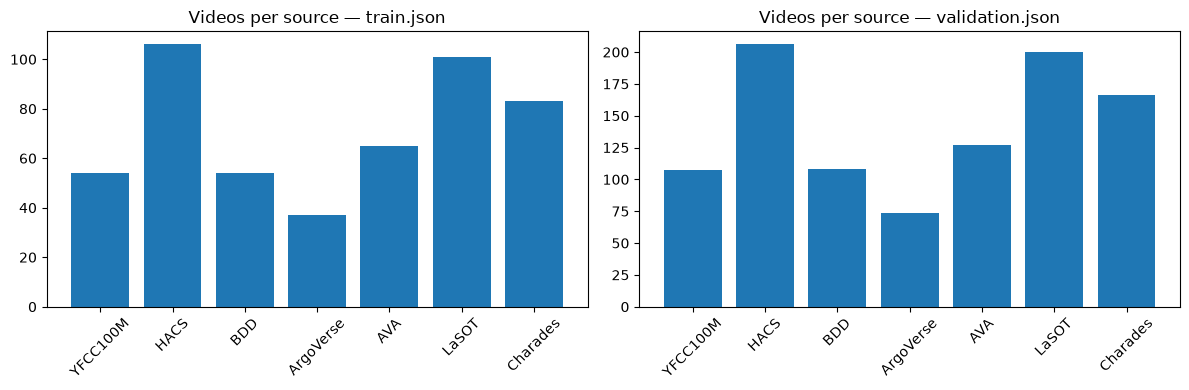

In [5]:
def source_counts(annotation_dict):
    counts = Counter()
    for v in annotation_dict["videos"]:
        # video "name" looks like "train/HACS/<video_id>" or "val/YFCC100M/<video_id>"
        parts = v["name"].split("/")
        counts[parts[1]] += 1
    return counts

train_src_counts = source_counts(train_data)
val_src_counts = source_counts(val_data)

print("train.json videos by source:", dict(train_src_counts))
print("validation.json videos by source:", dict(val_src_counts))

# quick bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in [
    (axes[0], train_src_counts, "train.json"),
    (axes[1], val_src_counts, "validation.json"),
]:
    ax.bar(counts.keys(), counts.values())
    ax.set_title(f"Videos per source — {title}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 0.4 Coverage check: which annotated videos do you actually have frames for?

This is the single most important cell in this notebook. It tells you
exactly what fraction of ASPIRe's train split you can currently use, broken
down by source dataset, so you know what still needs downloading before
Phase 2 (training).


In [6]:
def check_frame_coverage(annotation_dict, frames_root: Path, split_prefix: str):
    """
    For every video in the annotation file, check whether its frame folder
    exists on disk under frames_root.
    split_prefix: the first path component in video['name'], e.g. 'train' or 'val'.
    """
    results = []
    for v in annotation_dict["videos"]:
        parts = v["name"].split("/")  # e.g. ["train", "HACS", "video_folder_name"]
        prefix, source, video_folder = parts[0], parts[1], "/".join(parts[2:])
        local_dir = frames_root / prefix / source / video_folder
        results.append({
            "video_id": v["id"],
            "source": source,
            "name": v["name"],
            "local_dir": local_dir,
            "exists": local_dir.exists(),
            "n_frames_on_disk": len(list(local_dir.glob("*.jpg"))) if local_dir.exists() else 0,
        })
    return results

train_coverage = check_frame_coverage(train_data, FRAMES_ROOT, "train")

coverage_by_source = Counter()
present_by_source = Counter()
for r in train_coverage:
    coverage_by_source[r["source"]] += 1
    if r["exists"]:
        present_by_source[r["source"]] += 1

print("Train split — videos present locally / total annotated, by source:")
for source in coverage_by_source:
    total = coverage_by_source[source]
    present = present_by_source[source]
    print(f"  {source:12s}: {present:4d} / {total:4d}  ({present/total:.0%})")

total_present = sum(present_by_source.values())
total_all = sum(coverage_by_source.values())
print(f"\nOverall: {total_present} / {total_all} train videos have frames on disk ({total_present/total_all:.0%})")


Train split — videos present locally / total annotated, by source:
  YFCC100M    :    2 /   54  (4%)
  HACS        :    2 /  106  (2%)
  BDD         :    0 /   54  (0%)
  ArgoVerse   :    0 /   37  (0%)
  AVA         :    1 /   65  (2%)
  LaSOT       :    0 /  101  (0%)
  Charades    :    0 /   83  (0%)

Overall: 5 / 500 train videos have frames on disk (1%)


In [7]:
# Same check for validation.json against frames/train/ (expected to mostly fail,
# confirming the split-prefix mismatch described above) AND against
# frames/validation/ if you have it.

val_vs_train_frames = check_frame_coverage(val_data, FRAMES_ROOT, "val")
present = sum(1 for r in val_vs_train_frames if r["exists"])
print(f"validation.json videos resolvable under frames/train/: {present} / {len(val_vs_train_frames)}")
print("(If this is 0 or near-0, that confirms you need TAO-Amodal's validation "
      "frames separately before you can use ASPIRe's val split for evaluation.)")


validation.json videos resolvable under frames/train/: 0 / 988
(If this is 0 or near-0, that confirms you need TAO-Amodal's validation frames separately before you can use ASPIRe's val split for evaluation.)


## 0.5 Deep dive on a single frame entry

Let's look at exactly one entry from `data` and understand every field
before trusting any decoding logic.

Key structure (confirmed by inspection, not just the paper text):

```
entry = {
  "file_name": "train/HACS/<video>/frame0001.jpg",
  "image_id": int,
  "video_id": int,
  "segments_info": [ {"id", "track_id", "category_id", "isthing", "area"}, ... ],
  "annotations":   [ {"bbox", "bbox_mode", "category_id", "segmentation"}, ... ],
  "appearances":  [ [segment_idx, predicate_idx], ... ],
  "situations":   [ [segment_idx, predicate_idx], ... ],
  "positions":    [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
  "interactions": [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
  "relations":    [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
}
```

**Important gotcha #1:** the first number(s) in appearances/situations/
positions/interactions/relations are **positional indices into
`segments_info`/`annotations` for that frame** (0, 1, 2, 3, ...) — they are
**not** `track_id`. Don't confuse the two. `track_id` is what you use to
link the same subject across frames/time; the positional index is only
valid within that single frame entry.

**Important gotcha #2 (confirmed):** `category_id` is the real LVIS v0.5
category id — decode it through `LVIS_ID_TO_CAT` (loaded above), not through
ASPIRe's own `thing_classes`/`stuff_classes` arrays.


In [20]:
sample_entry = train_data["data"][0]
print(json.dumps(sample_entry, indent=2))


{
  "file_name": "train/YFCC100M/v_f69ebe5b731d3e87c1a3992ee39c3b7e/frame0391.jpg",
  "pan_seg_file_name": "train/YFCC100M/v_f69ebe5b731d3e87c1a3992ee39c3b7e/frame0391.jpg",
  "height": 480,
  "width": 640,
  "image_id": 0,
  "video_id": 0,
  "segments_info": [
    {
      "id": 0,
      "track_id": 0,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 4757
    },
    {
      "id": 1,
      "track_id": 1,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 45150
    },
    {
      "id": 2,
      "track_id": 2,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 5251
    },
    {
      "id": 3,
      "track_id": 3,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 32160
    },
    {
      "id": 4,
      "track_id": 4,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 3198
    },
    {
      "id": 5,
      "track_id": 5,
      "category_id": 805

In [46]:
train_data["predicate_appearances"][522]

'hat and is'

In [10]:
def decode_category(category_id):
    """
    Look up the real object category name via the LVIS v0.5 id -> name
    mapping. `synonyms[0]` (LVIS's 'name' field) can be a slightly odd
    synonym (e.g. category id 805's name is 'baby' even though it covers
    any person - man/woman/child/human), so we show all synonyms for
    clarity rather than just the primary name.
    """
    print("Category ID: ", category_id)
    cat = LVIS_ID_TO_CAT.get(category_id)
    if cat is None:
        return f"<unknown category_id={category_id}>"
    return cat["name"]
    # return cat["name"] + "  (synonyms: " + ", ".join(cat["synonyms"]) + ")"


def decode_predicate(annotation_dict, predicate_list_name, predicate_idx):
    plist = annotation_dict[predicate_list_name]
    if 0 <= predicate_idx < len(plist):
        return plist[predicate_idx]
    return f"<unknown idx={predicate_idx}>"


# Decode every field of the sample entry into human-readable form
print("=== Segments (subjects present in this frame) ===")
for i, seg in enumerate(sample_entry["segments_info"]):
    cat_name = decode_category(seg["category_id"])
    print(f"  [{i}] track_id={seg['track_id']}  category_id={seg['category_id']} -> {cat_name}")

print("\n=== Appearances (single-actor) ===")
for seg_idx, pred_idx in sample_entry["appearances"]:
    pred = decode_predicate(train_data, "predicate_appearances", pred_idx)
    print(f"  segment[{seg_idx}] -> appearance: '{pred}'")

print("\n=== Situations (single-actor) ===")
for seg_idx, pred_idx in sample_entry["situations"]:
    print("pred_idx: ", pred_idx)
    pred = decode_predicate(train_data, "predicate_situations", pred_idx)
    print(f"  segment[{seg_idx}] -> situation: '{pred}'")

print("\n=== Positions (double-actor) ===")
for i, j, pred_idx in sample_entry["positions"]:
    pred = decode_predicate(train_data, "predicate_positions", pred_idx)
    print(f"  segment[{i}] -- position: '{pred}' --> segment[{j}]")

print("\n=== Interactions (double-actor) ===")
for i, j, pred_idx in sample_entry["interactions"]:
    pred = decode_predicate(train_data, "predicate_interactions", pred_idx)
    print(f"  segment[{i}] -- interaction: '{pred}' --> segment[{j}]")

print("\n=== Relations (double-actor) ===")
for i, j, pred_idx in sample_entry["relations"]:
    pred = decode_predicate(train_data, "predicate_relations", pred_idx)
    print(f"  segment[{i}] -- relation: '{pred}' --> segment[{j}]")


=== Segments (subjects present in this frame) ===
Category ID:  805
  [0] track_id=0  category_id=805 -> person
Category ID:  805
  [1] track_id=1  category_id=805 -> person
Category ID:  805
  [2] track_id=2  category_id=805 -> person
Category ID:  805
  [3] track_id=3  category_id=805 -> person
Category ID:  805
  [4] track_id=4  category_id=805 -> person
Category ID:  805
  [5] track_id=5  category_id=805 -> person

=== Appearances (single-actor) ===
  segment[0] -> appearance: 'helmet and is'
  segment[1] -> appearance: 'helmet and is'
  segment[2] -> appearance: 'hat and is'
  segment[3] -> appearance: 'hat and is'
  segment[4] -> appearance: 'helmet and is'
  segment[5] -> appearance: 'hat and is'

=== Situations (single-actor) ===
pred_idx:  1268
  segment[0] -> situation: 'listen to him'
pred_idx:  1515
  segment[1] -> situation: 'ocean by itself'
pred_idx:  1851
  segment[2] -> situation: 'pushed by someone else'
pred_idx:  1803
  segment[3] -> situation: 'prisoner of the Germ

## 0.5b Category label reliability — important finding

Empirically checking `category_id` across the whole `train.json`:

- **100% of frames with 2+ segments have every segment sharing the exact
  same `category_id`** — e.g. 10 clearly distinct people in a drum-corps
  frame all labeled `405` (`drum_(musical_instrument)`) instead of `person`.
- Only **~68% of individual tracks** keep a single consistent `category_id`
  across their own lifetime — a real object/person track should never
  change category, so this confirms the field is noisy at the instance
  level, not just occasionally wrong.

**Conclusion: treat `category_id` as an unreliable, coarse/frame-level tag,
not a trustworthy per-instance object label.** Don't build a classification
target or a node "object identity" feature on top of it. This doesn't
undermine your overall plan — ASPIRe's real payload is the five
open-vocabulary relational attributes (Appearance, Situation, Position,
Interaction, Relation), which are annotated independently and don't share
this bug (see the `appearances`/`situations` text for these same tracks in
0.5 above). Node identity for your relation model should come from the
**visual crop embedding + Appearance/Situation text**, not `category_id`.


In [11]:
from collections import defaultdict

# Reproduce the two checks above on your own copy of the data.

# 1) Within-frame category agreement
same_frame, mixed_frame = 0, 0
for e in train_data["data"]:
    cats = [s["category_id"] for s in e["segments_info"]]
    if len(cats) < 2:
        continue
    if len(set(cats)) == 1:
        same_frame += 1
    else:
        mixed_frame += 1
total_multi = same_frame + mixed_frame
print(f"Frames with 2+ segments: {total_multi}")
print(f"  all segments share category_id: {same_frame} ({same_frame/total_multi:.1%})")
print(f"  mixed categories in-frame:      {mixed_frame} ({mixed_frame/total_multi:.1%})")

# 2) Per-track category consistency over the video's lifetime
track_cats = defaultdict(set)
for e in train_data["data"]:
    for s in e["segments_info"]:
        track_cats[s["track_id"]].add(s["category_id"])

consistent = sum(1 for c in track_cats.values() if len(c) == 1)
print(f"\nTotal tracks: {len(track_cats)}")
print(f"Tracks with one consistent category_id over their lifetime: "
      f"{consistent} ({consistent/len(track_cats):.1%})")


Frames with 2+ segments: 14328
  all segments share category_id: 14328 (100.0%)
  mixed categories in-frame:      0 (0.0%)

Total tracks: 2647
Tracks with one consistent category_id over their lifetime: 1789 (67.6%)


## 0.6 Visual sanity check — draw boxes + decoded labels on a real frame

This is the ground-truth check for everything above. If `category_id`
decoding is wrong, or bboxes are in the wrong coordinate convention, you
will see it immediately here (box in the wrong place, or a label that
clearly doesn't match what's in the box).

`bbox` format per the paper/TAO convention is `[x, y, width, height]` in
pixel coordinates, top-left origin.


{
  "file_name": "train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0001.jpg",
  "pan_seg_file_name": "train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0001.jpg",
  "height": 480,
  "width": 640,
  "image_id": 112,
  "video_id": 3,
  "segments_info": [
    {
      "id": 561,
      "track_id": 16,
      "category_id": 95,
      "iscrowd": 0,
      "isthing": 1,
      "area": 10140
    },
    {
      "id": 562,
      "track_id": 17,
      "category_id": 95,
      "iscrowd": 0,
      "isthing": 1,
      "area": 26416
    },
    {
      "id": 563,
      "track_id": 18,
      "category_id": 95,
      "iscrowd": 0,
      "isthing": 1,
      "area": 34500
    }
  ],
  "annotations": [
    {
      "bbox": [
        16,
        202,
        65,
        156
      ],
      "segmentation": [
        16,
        202,
        65,
        156
      ],
      "bbox_mode": 0,
      "category_id": 805
    },
    {
      "bbox": [
        371,
        226,
        104,
        254
      ],
    

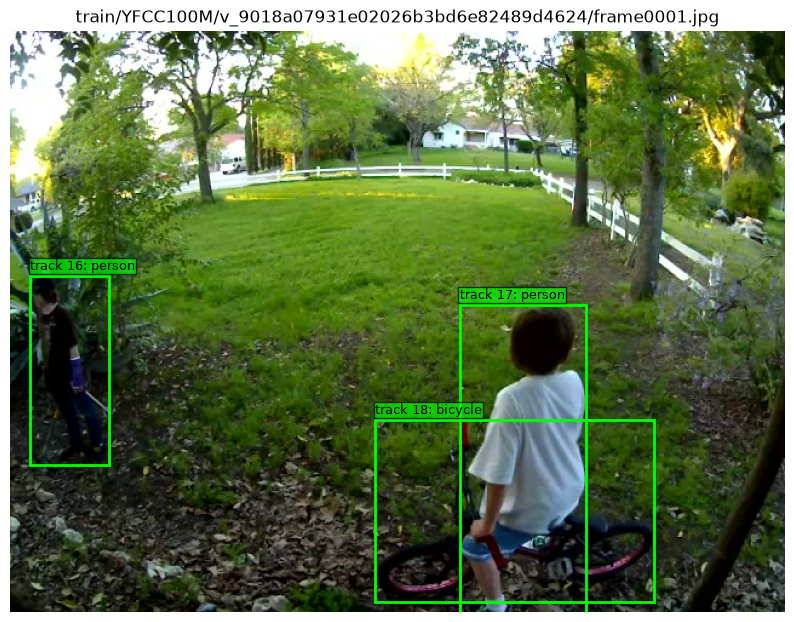


Double-actor attributes for this frame:
  track 16 --[position: around the cones]--> track 17
  track 16 --[interaction: eating with]--> track 17
  track 16 --[relation: coach and athlete]--> track 17

  track 0 -- [situation: blue and is]
  track 1 -- [situation: hat and is]
  track 2 -- [situation: hat and is]
  track 0 -- [situation: largest of the three]
  track 1 -- [situation: stained with something]
  track 2 -- [situation: prisoner of the Germans]


In [45]:
def find_first_available_entry(annotation_dict, frames_root: Path, split_prefix: str):
    """Return the first data entry whose frame file actually exists on disk."""
    for entry in annotation_dict["data"]:
        local_path = frames_root / entry["file_name"]
        if local_path.exists():
            return entry, local_path
    return None, None


sample_entry, sample_path = find_first_available_entry(train_data, FRAMES_ROOT, "train")
print(json.dumps(sample_entry, indent=2))

if sample_entry is None:
    print("No annotated frame from train.json currently exists on disk under",
          FRAMES_ROOT, "\n-> download more frame folders before this check will work.")
else:
    print("Using:", sample_path)
    img = Image.open(sample_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    for seg, ann in zip(sample_entry["segments_info"], sample_entry["annotations"]):
        x, y, w, h = ann["bbox"]
        cat_name = decode_category(ann["category_id"])
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 5, 0), f"track {seg['track_id']}: {cat_name}",
                 color="black", fontsize=9,
                 bbox=dict(facecolor="lime", alpha=0.7, pad=1))

    ax.set_title(sample_entry["file_name"])
    ax.axis("off")
    plt.show()

    print("\nDouble-actor attributes for this frame:")
    seg_track_ids = [s["track_id"] for s in sample_entry["segments_info"]]
    for attr_name, attr_list in [
        ("position", sample_entry["positions"]),
        ("interaction", sample_entry["interactions"]),
        ("relation", sample_entry["relations"]),
    ]:
        pred_list_name = f"predicate_{attr_name}s"
        for i, j, pred_idx in attr_list:
            pred = decode_predicate(train_data, pred_list_name, pred_idx)
            print(f"  track {seg_track_ids[i]} --[{attr_name}: {pred}]--> track {seg_track_ids[j]}")

    print()
    for attr_name, attr_list in [
        ("appearance", sample_entry["appearances"]),
        ("situation", sample_entry["situations"]),
    ]:
        pred_list_name = f"predicate_{attr_name}s"
        for seg_idx, pred_idx in attr_list:
            pred = decode_predicate(train_data, pred_list_name, pred_idx)
            print(f"  track {seg_idx} -- [situation: {pred}]")

**Stop and look at the plot above.** Ask yourself:
- Do the boxes actually sit on the right objects/people?
- Does the decoded category name plausibly match what's in the box?

Category decoding now goes through the real LVIS v0.5 `id -> name` mapping,
so it should be correct. If a name still looks wrong here, it likely means
the box itself is misplaced/mislabeled in the source annotation (which does
happen — TAO's own quality analysis found ~93% category agreement on
re-annotation, i.e. a small but real noise floor), not a decoding bug.


## 0.6b Multi-source spot-check

Section 0.6 only looked at one frame from one video (the HACS drum-corps
clip). Before drawing conclusions about how widespread the `category_id`
issue is, look at one frame from **each source dataset you actually have
on disk** (AVA, HACS, BDD, Charades, LaSOT, YFCC100M, ArgoVerse — whichever
subset you've downloaded). This cell finds the first available frame per
source and draws it, so you can eyeball several independent videos in one
pass instead of editing paths by hand each time.


In [13]:
found_list = []
found = {}
for entry in train_data["data"]:
  local_path = FRAMES_ROOT / entry["file_name"]
  
  if not local_path.exists():
    continue
  # print(local_path)
  
  source = entry["file_name"].split("/")[1]  # e.g. "train/HACS/..." -> "HACS"
  if len(found_list) < 5:
    found[source] = (entry, local_path)
    found_list.append(found)
    
print(found_list)

[{'YFCC100M': ({'file_name': 'train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0121.jpg', 'pan_seg_file_name': 'train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0121.jpg', 'height': 480, 'width': 640, 'image_id': 116, 'video_id': 3, 'segments_info': [{'id': 577, 'track_id': 16, 'category_id': 95, 'iscrowd': 0, 'isthing': 1, 'area': 10540}, {'id': 578, 'track_id': 17, 'category_id': 95, 'iscrowd': 0, 'isthing': 1, 'area': 26536}, {'id': 579, 'track_id': 18, 'category_id': 95, 'iscrowd': 0, 'isthing': 1, 'area': 35495}], 'annotations': [{'bbox': [13, 202, 68, 155], 'segmentation': [13, 202, 68, 155], 'bbox_mode': 0, 'category_id': 805}, {'bbox': [382, 232, 107, 248], 'segmentation': [382, 232, 107, 248], 'bbox_mode': 0, 'category_id': 805}, {'bbox': [302, 317, 229, 155], 'segmentation': [302, 317, 229, 155], 'bbox_mode': 0, 'category_id': 95}], 'appearances': [[0, 109], [1, 522], [2, 522]], 'situations': [[0, 1862], [1, 1293], [2, 1293]], 'positions': [[0, 1, 60]], 'interacti

In [16]:
def find_available_entries_per_source(annotation_dict, frames_root: Path,
                                       n_per_source=3, distinct_videos=True,
                                       seed=42):
    """
    Return a dict: source_name -> list of (entry, local_path), up to
    n_per_source items, for frames that exist on disk.

    distinct_videos=True (recommended): sample from different videos within
    a source rather than multiple frames of the same video back-to-back --
    much more informative for spot-checking whether the category_id issue
    is video-specific or dataset-wide.
    """
    # group available entries by source, then by video_id
    by_source_video = defaultdict(lambda: defaultdict(list))
    for entry in annotation_dict["data"]:
        local_path = frames_root / entry["file_name"]
        if not local_path.exists():
            continue
        source = entry["file_name"].split("/")[1]
        by_source_video[source][entry["video_id"]].append((entry, local_path))

    rng = random.Random()
    result = {}
    for source, videos in by_source_video.items():
        video_ids = list(videos.keys())
        rng.shuffle(video_ids)
        picked = []
        if distinct_videos:
            # one frame from each of up to n_per_source distinct videos
            for vid in video_ids[:n_per_source]:
                frames = videos[vid]
                picked.append(rng.choice(frames))
        else:
            # just pool everything and sample n_per_source frames total
            pool = [item for frames in videos.values() for item in frames]
            rng.shuffle(pool)
            picked = pool[:n_per_source]
        result[source] = picked
    return result


# --- Configure how many frames per source you want to compare ---
N_FRAMES_PER_SOURCE = 5   # change this to inspect more/fewer frames at once
DISTINCT_VIDEOS = True    # True = sample from different videos (recommended)

entries_by_source = find_available_entries_per_source(
    train_data, FRAMES_ROOT,
    n_per_source=N_FRAMES_PER_SOURCE,
    distinct_videos=DISTINCT_VIDEOS,
)

total_frames = sum(len(v) for v in entries_by_source.values())
print(f"Found {total_frames} frame(s) across {len(entries_by_source)} source(s): "
      f"{ {k: len(v) for k, v in entries_by_source.items()} }")

if not entries_by_source:
    print("No frames found on disk yet under", FRAMES_ROOT)


Found 5 frame(s) across 3 source(s): {'YFCC100M': 2, 'HACS': 2, 'AVA': 1}


Category ID:  533
pred_situation:  toasting in the oven
pred_appearance:  hat and is
Category ID:  805
pred_situation:  toasting in the oven
pred_appearance:  hat and is
Category ID:  805
pred_situation:  toasting in the oven
pred_appearance:  hat and is


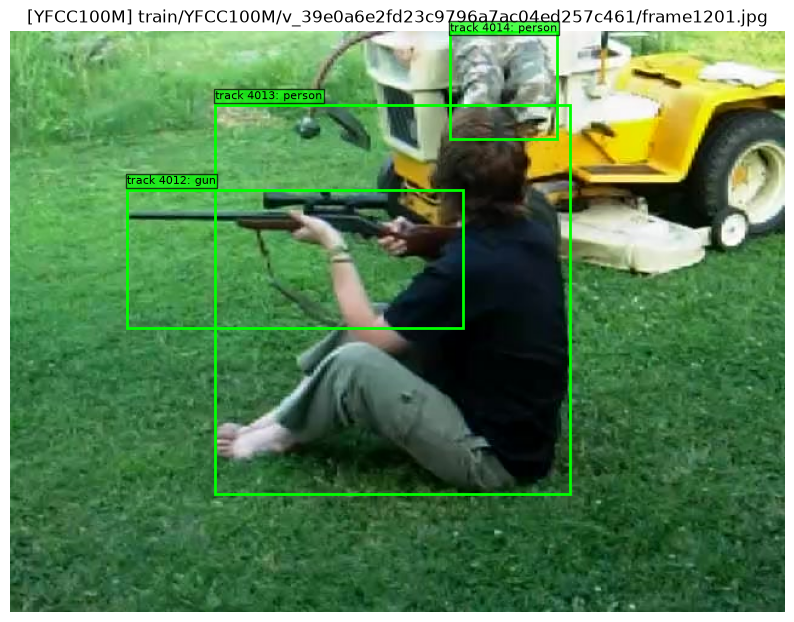

  3 segment(s), 2 distinct category name(s) in this frame

Category ID:  805
pred_situation:  questioned by the feds
pred_appearance:  helmet and is
Category ID:  805
pred_situation:  watched by someone high
pred_appearance:  hat and is
Category ID:  95
pred_situation:  watched by someone high
pred_appearance:  hat and is


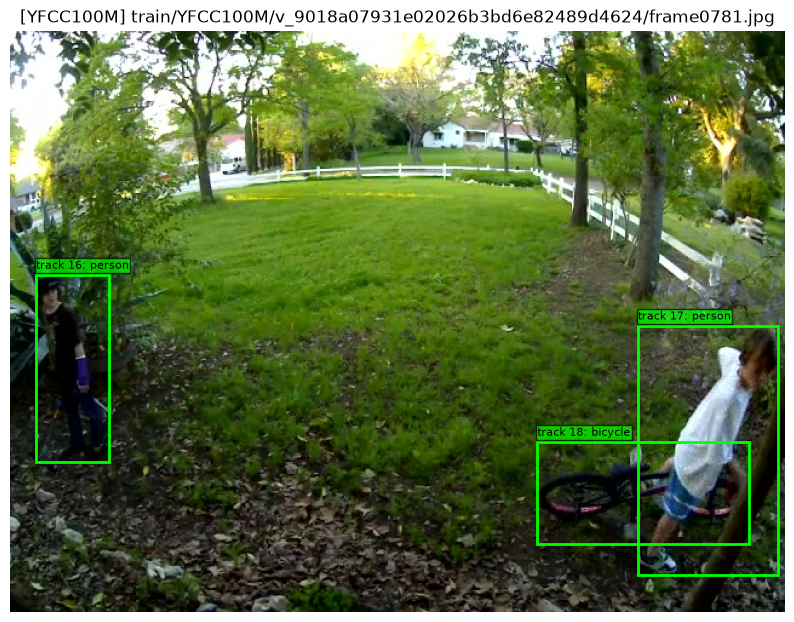

  3 segment(s), 2 distinct category name(s) in this frame

Category ID:  805
pred_situation:  stepping up and down
pred_appearance:  blue and is
Category ID:  805
pred_situation:  listen to him
pred_appearance:  helmet and is
Category ID:  805
pred_situation:  standing there
pred_appearance:  hat and is
Category ID:  805
pred_situation:  standing there
pred_appearance:  hat and is
Category ID:  405
pred_situation:  standing there
pred_appearance:  hat and is
Category ID:  405
pred_situation:  standing there
pred_appearance:  hat and is


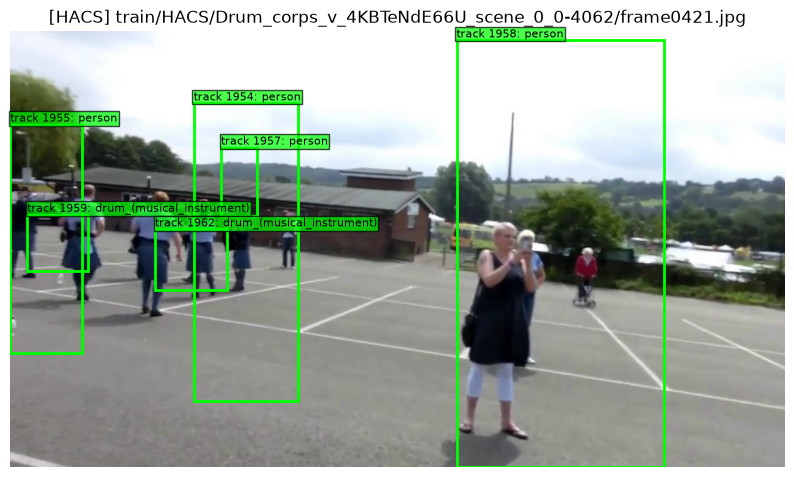

  6 segment(s), 2 distinct category name(s) in this frame

Category ID:  162
pred_situation:  talking to her
pred_appearance:  eyes and is


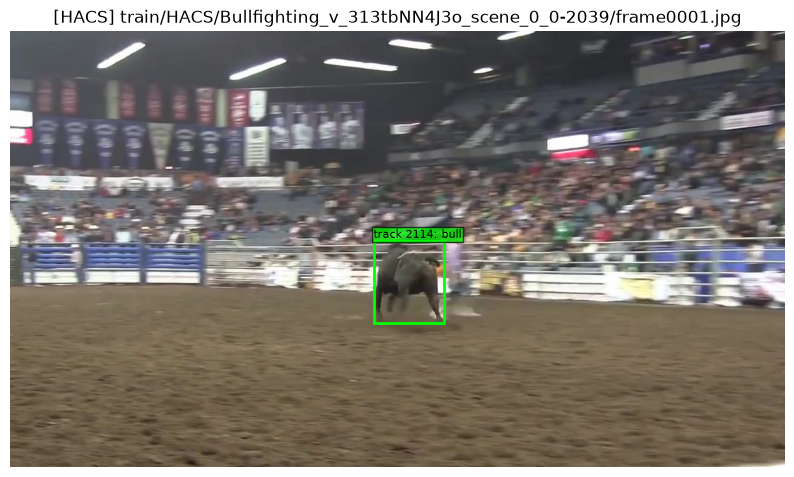

  1 segment(s), 1 distinct category name(s) in this frame

Category ID:  805
pred_situation:  ocean by itself
pred_appearance:  helmet and is
Category ID:  805
pred_situation:  line for something
pred_appearance:  helmet and is


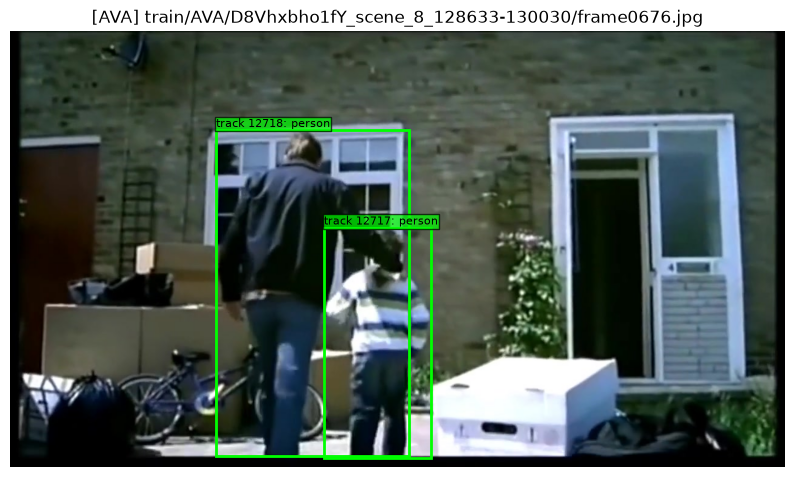

  2 segment(s), 1 distinct category name(s) in this frame

=== Summary across all sampled frames ===
source       segments  distinct_cats file_name
YFCC100M             3             2 train/YFCC100M/v_39e0a6e2fd23c9796a7ac04ed257c461/frame1201.jpg
YFCC100M             3             2 train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0781.jpg
HACS                 6             2 train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062/frame0421.jpg
HACS                 1             1 train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0001.jpg
AVA                  2             1 train/AVA/D8Vhxbho1fY_scene_8_128633-130030/frame0676.jpg  <-- single category for multiple segments


In [17]:
# Draw each sampled frame. To check SPECIFIC sources instead of all of them,
# set: sources_to_check = ["HACS", "AVA"]  (or whichever you want)
sources_to_check = list(entries_by_source.keys())

summary_rows = []  # (source, file_name, n_segments, n_distinct_cats)

for source in sources_to_check:
    for entry, path in entries_by_source[source]:
        img = Image.open(path).convert("RGB")

        fig, ax = plt.subplots(1, figsize=(10, 8))
        ax.imshow(img)

        cats_in_frame = set()
        for seg, ann, (sit_seg_idx, sit_pred_idx), (app_seg_idx, app_pred_idx) in zip(entry["segments_info"], entry["annotations"], entry["situations"], entry["appearances"]):
            
            x, y, w, h = ann["bbox"]
            cat_name = decode_category(ann["category_id"])
            
            pred_situation = decode_predicate(train_data, "predicate_situations", sit_pred_idx)
            pred_appearances = decode_predicate(train_data, "predicate_appearances", app_pred_idx)
            # pred_interactions = decode_predicate(train_data, "predicate_interactions", inter_pred_idx)
            
            print("pred_situation: ", pred_situation)
            print("pred_appearance: ", pred_appearances)
            # print("pred_interactions: ", pred_interactions)
            
            cats_in_frame.add(cat_name)
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(x, max(y - 5, 0), f"track {seg['track_id']}: {cat_name}",
                     color="black", fontsize=8,
                     bbox=dict(facecolor="lime", alpha=0.7, pad=1))

        ax.set_title(f"[{source}] {entry['file_name']}")
        ax.axis("off")
        plt.show()

        n_segments = len(entry["segments_info"])
        n_distinct_cats = len(cats_in_frame)
        print(f"  {n_segments} segment(s), {n_distinct_cats} distinct category name(s) in this frame")
        print()
        summary_rows.append((source, entry["file_name"], n_segments, n_distinct_cats))

# Compact summary table across every frame just shown
print("=== Summary across all sampled frames ===")
print(f"{'source':12s} {'segments':9s} {'distinct_cats':13s} file_name")
for source, fname, n_seg, n_cats in summary_rows:
    flag = "  <-- single category for multiple segments" if (n_seg > 1 and n_cats == 1) else ""
    print(f"{source:12s} {n_seg:9d} {n_cats:13d} {fname}{flag}")


Look across the outputs above:
- Do different sources show different (varied) categories, or does every
  source also show the "all segments = one identical category" pattern?
- If it's consistently one-category-per-frame across *every* source, that
  confirms the 0.5b finding is dataset-wide, not specific to this one HACS
  video, and you should proceed treating `category_id` as unreliable
  everywhere. If some sources look fine and only certain ones (e.g. HACS
  action clips specifically) show the issue, that's worth narrowing down
  further and noting as a source-specific caveat instead of a blanket one.


## 0.7 Track continuity across frames of the same video

Since your downstream model needs to reason across a temporal window, check
that `track_id` is in fact stable across frames of the same video (same
subject keeps the same `track_id` from one annotated frame to the next).


In [18]:
def frames_for_video(annotation_dict, video_id):
    entries = [e for e in annotation_dict["data"] if e["video_id"] == video_id]
    entries.sort(key=lambda e: e["file_name"])
    return entries


# pick a video that has more than one annotated frame
video_frame_counts = Counter(e["video_id"] for e in train_data["data"])
candidate_video_id = None
for vid, count in video_frame_counts.most_common():
    entries = frames_for_video(train_data, vid)
    # prefer one where at least one frame resolves locally
    if any((FRAMES_ROOT / e["file_name"]).exists() for e in entries):
        candidate_video_id = vid
        break

if candidate_video_id is not None:
    entries = frames_for_video(train_data, candidate_video_id)
    print(f"video_id={candidate_video_id} has {len(entries)} annotated frames")
    for e in entries:
        track_ids = [s['track_id'] for s in e['segments_info']]
        on_disk = (FRAMES_ROOT / e['file_name']).exists()
        print(f"  {e['file_name']:60s} track_ids={track_ids}  on_disk={on_disk}")
else:
    print("No multi-frame video found with any frame available locally yet.")


video_id=330 has 40 annotated frames
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0001.jpg track_ids=[2114]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0031.jpg track_ids=[2114, 2115, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0061.jpg track_ids=[2114, 2115, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0091.jpg track_ids=[2114, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0121.jpg track_ids=[2114, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0151.jpg track_ids=[2114, 2115, 2116, 2117, 2118]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0181.jpg track_ids=[2114, 2115, 2116, 2121, 2117, 2118]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0211.jpg track_ids=[2114, 2116, 2121, 211

## 0.8 Label distribution (long-tail check)

Quick frequency counts per attribute type, restricted to `train.json`. This
is just to confirm the paper's claim that these distributions are heavily
long-tailed — which will directly affect your loss design in Phase 1
(focal loss, class weighting, or a "top-K classes + other" simplification).


In [19]:
def attribute_frequency(annotation_dict, data_field, predicate_field, top_n=15):
    counter = Counter()
    for entry in annotation_dict["data"]:
        for item in entry[data_field]:
            pred_idx = item[-1]  # predicate index is always last element
            counter[pred_idx] += 1
    predicate_list = annotation_dict[predicate_field]
    most_common = counter.most_common(top_n)
    return [(predicate_list[idx], cnt) for idx, cnt in most_common], len(counter)


for data_field, predicate_field in [
    ("appearances", "predicate_appearances"),
    ("situations", "predicate_situations"),
    ("positions", "predicate_positions"),
    ("interactions", "predicate_interactions"),
    ("relations", "predicate_relations"),
]:
    top, n_unique_used = attribute_frequency(train_data, data_field, predicate_field)
    print(f"\n{data_field} — {n_unique_used} distinct predicates actually used in train.json")
    for name, cnt in top:
        print(f"  {cnt:5d}  {name}")



appearances — 18 distinct predicates actually used in train.json
  31522  hat and is
  15132  helmet and is
   4150  blue and is
   1648  cover and is
   1498  eyes and is
    300  bike and eating
    116  black and red
     76  bike and crying
     61  arrows and looks
     49  club and looking
     36  bike and yelling
     25  head and is
     11  delicious and well
      5  lawn and looking
      5  colored and beautifully

situations — 236 distinct predicates actually used in train.json
  11282  toasting in the oven
   5892  prisoner of the Germans
   2130  looking at each other
   2024  standing by itself
   1999  prisoner of the Gestapo
   1866  blending something
   1853  toasted in the oven
   1845  listen to him
   1673  leading the other
   1336  skating with someone else
   1277  put in the oven
   1249  broken down taillight
   1004  wanted for Christmas
    980  picking up the white
    971  largest of the three

positions — 46 distinct predicates actually used in train.

## 0.9 Summary — what to do before Phase 1

Fill this in after running the notebook on your machine:

- [ ] % of `train.json` videos with frames on disk: ______
- [ ] Sources still needed for full train coverage: ______
- [ ] Confirmed `category_id` decoding uses the real LVIS mapping (visual
      check passed / failed): ______
- [ ] Noted that `category_id` is unreliable at the instance level (0.5b) —
      plan to use visual crop + Appearance/Situation text for node identity
      instead: ______
- [ ] Confirmed `track_id` is stable across frames within a video: ______
- [ ] Do you have (or need to download) TAO-Amodal `frames/validation/` for
      ASPIRe's val split: ______
- [ ] Long-tail severity noted for loss design in Phase 1: ______

Once these are answered, we can move to Phase 1: the simplified
graph/transformer relation model (node feature extraction, k-NN graph
construction, GAT/TransformerConv layers, multi-head focal loss).
